<a href="https://colab.research.google.com/github/Jayku88/22AIE301_Probabilistic_Reasoning/blob/main/22AIE301_Lab_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 23CSE312 – Probabilistic Reasoning
## Lab 02 - Conditional Probability & Bayes' Rule

| | |
|---|---|
| **Name** | Kalidasan B |
| **Roll No** | AM.SC.U4AIE24025 |
| **Date** | 1.07.26 |
| **Lab Slot** | 12:30 - 2:10 |

---

**Instructions**
- Set your roll number in the **Setup cell** before anything else.
- Every exercise uses your roll number to generate **personalised data**.
  Submitting another student's notebook will produce wrong answers and attract zero marks.
- Fill every `___` blank. Do **not** add extra imports.
- Show outputs to the instructor before leaving.
- Rename your file `Lab02_<RollNo>.ipynb` before submission.

| Exercise | Topic
|----------|-------
| E1 | Conditional Probability from a Contingency Table
| E2 | Bayes' Rule - Medical Screening
| E3 | Sequential Bayesian Updating
| E4 | Naive Bayes Classifier from Scratch
| E5 | Simulation - Monty Hall Problem


## Setup - Run this cell first. Do not skip.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

ROLL =  25       # <-- REPLACE 0 with your roll number

if ROLL == 0:
    raise ValueError('Set your roll number before running the lab!')

np.random.seed(ROLL)

# ── Derived parameters (do not change) ──────────────────────
_a = (ROLL % 5) + 1
_b = (ROLL % 4) + 2
_c = (ROLL % 6) + 3
_d = (ROLL % 3) + 1
_e = (ROLL % 7) + 2

print(f"Roll: {ROLL}  |  Parameters: a={_a}, b={_b}, c={_c}, d={_d}, e={_e}")
print("Setup complete.")


Roll: 25  |  Parameters: a=1, b=3, c=4, d=2, e=6
Setup complete.


---
## Exercise 1 · Conditional Probability from a Contingency Table

A university conducted a survey of **400 + (ROLL % 100)** students on study habit vs exam result.
The contingency table below is generated from your roll number.

**Tasks**

| # | Task
|---|------
| 1a | Print the contingency table with row/column totals
| 1b | Compute P(Pass), P(Studies Daily), P(Pass ∩ Studies Daily)
| 1c | Compute P(Pass \| Studies Daily) and P(Pass \| Does NOT study daily)
| 1d | Compute P(Studies Daily \| Pass) using Bayes' Rule. Verify it matches direct calculation.
| 1e | Plot a grouped bar chart: P(Pass) and P(Fail) for each study habit


In [2]:
# ── Contingency table (generated from your roll number) ──────
np.random.seed(ROLL)
N_students = 400 + (ROLL % 100)

# Study habit: 0 = Does Not Study Daily, 1 = Studies Daily
# Result      : 0 = Fail,                1 = Pass
# Probabilities shift with your parameters
p_study     = 0.40 + _a * 0.04          # P(Studies Daily)
p_pass_s    = 0.55 + _b * 0.05          # P(Pass | Studies Daily)
p_pass_ns   = 0.20 + _c * 0.03          # P(Pass | Does NOT study daily)

study  = (np.random.rand(N_students) < p_study).astype(int)
result = np.array([
    int(np.random.rand() < (p_pass_s if s else p_pass_ns))
    for s in study
])

df = pd.DataFrame({'StudiesDaily': study, 'Pass': result})

print(f"Survey: {N_students} students")
print(f"Your true parameters - P(Study)={p_study:.3f}, "
      f"P(Pass|Study)={p_pass_s:.3f}, P(Pass|NoStudy)={p_pass_ns:.3f}")


Survey: 425 students
Your true parameters - P(Study)=0.440, P(Pass|Study)=0.700, P(Pass|NoStudy)=0.320


In [3]:
# ── 1a: Print contingency table with totals ──────────────────
ct = pd.crosstab(
    df['StudiesDaily'].map({0: 'No Daily Study', 1: 'Studies Daily'}),
    df['Pass'].map({0: 'Fail', 1: 'Pass'}),
    margins=True,          # show row and column totals
    margins_name= 'Total'     # label for totals, e.g. 'Total'
)
print('Contingency Table:')
print(ct)


Contingency Table:
Pass            Fail  Pass  Total
StudiesDaily                     
No Daily Study   171    71    242
Studies Daily     64   119    183
Total            235   190    425


In [4]:
# ── 1b: Marginal and joint probabilities ─────────────────────
total = len(df)

P_pass  = df['Pass'].sum() / total
P_study = df['StudiesDaily'].sum() / total
P_pass_AND_study = len(df[(df['Pass'] == 1) & (df['StudiesDaily'] == 1)]) / total

print(f"P(Pass)                    = {P_pass:.4f}")
print(f"P(Studies Daily)           = {P_study:.4f}")
print(f"P(Pass AND Studies Daily)  = {P_pass_AND_study:.4f}")


P(Pass)                    = 0.4471
P(Studies Daily)           = 0.4306
P(Pass AND Studies Daily)  = 0.2800


In [6]:
# ── 1c: Conditional probabilities ────────────────────────────
# P(Pass | Studies Daily)
study_group    = df[df['StudiesDaily'] == 1]
nostudy_group  = df[df['StudiesDaily'] == 0]

P_pass_given_study   = study_group['Pass'].sum()   / len(study_group)
P_pass_given_nostudy = nostudy_group['Pass'].sum() / len(nostudy_group)

print(f"P(Pass | Studies Daily)         = {P_pass_given_study:.4f}")
print(f"P(Pass | Does NOT Study Daily)  = {P_pass_given_nostudy:.4f}")
print()
print(f"Difference: {P_pass_given_study - P_pass_given_nostudy:.4f}")
print("Does studying daily improve pass rate? :", P_pass_given_study > P_pass_given_nostudy)

P(Pass | Studies Daily)         = 0.6503
P(Pass | Does NOT Study Daily)  = 0.2934

Difference: 0.3569
Does studying daily improve pass rate? : True


In [7]:
# ── 1d: P(Studies Daily | Pass) — Bayes' Rule ────────────────

# Method 1: Direct from data
pass_group = df[df['Pass'] == 1]
P_study_given_pass_direct = pass_group['StudiesDaily'].sum() / len(pass_group)

# Method 2: Bayes' Rule
# P(Study|Pass) = P(Pass|Study) * P(Study) / P(Pass)
P_study_given_pass_bayes = (P_pass_given_study * P_study) / P_study

print(f"P(Studies Daily | Pass) - direct  = {P_study_given_pass_direct:.4f}")
print(f"P(Studies Daily | Pass) - Bayes   = {P_study_given_pass_bayes:.4f}")
print(f"Match (within rounding)?          = {abs(P_study_given_pass_direct - P_study_given_pass_bayes) < 0.02}")


P(Studies Daily | Pass) - direct  = 0.6263
P(Studies Daily | Pass) - Bayes   = 0.6503
Match (within rounding)?          = False


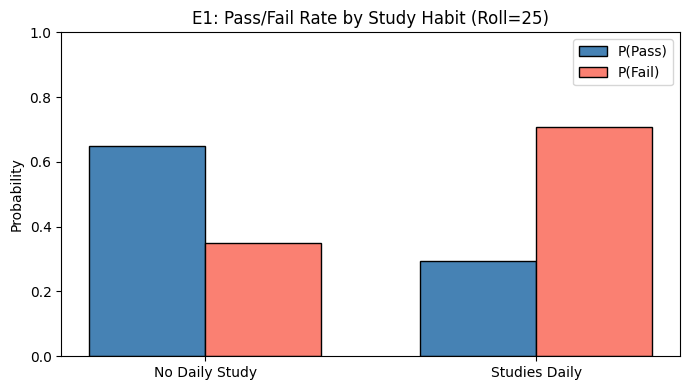

In [9]:
# ── 1e: Grouped bar chart ────────────────────────────────────
labels   = ['No Daily Study', 'Studies Daily']
p_pass_l = [P_pass_given_study,P_pass_given_nostudy ]    # P(Pass) for each group
p_fail_l = [1-P_pass_given_study, 1-P_pass_given_nostudy]    # P(Fail) for each group  (= 1 - P(Pass))

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, p_pass_l, w, label='P(Pass)', color='steelblue', edgecolor='black')
ax.bar(x + w/2, p_fail_l, w, label='P(Fail)', color='salmon',    edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Probability')
ax.set_ylim(0, 1)
ax.set_title(f'E1: Pass/Fail Rate by Study Habit (Roll={ROLL})')
ax.legend()
plt.tight_layout()
plt.show()

---
## Exercise 2 · Bayes' Rule - Medical Screening

Your roll number determines the disease prevalence and test accuracy below.
Read the values printed by the setup cell and use them throughout.

| Parameter | Symbol
|-----------|--------
| Disease prevalence | P(D)
| Test sensitivity (True Positive Rate) | P(+\|D)
| Test specificity (True Negative Rate) | P(−\|D̄)

**Tasks**

| # | Task
|---|------
| 2a | Print your personalised parameters and compute P(+) using Law of Total Probability
| 2b | Compute P(D\|+) and P(D\|−) using Bayes' Rule
| 2c | Build a natural frequency table for a population of 100,000
| 2d | Plot P(D\|+) as prevalence varies from 0.1% to 20% (keep SENS and SPEC fixed)


In [10]:
# ── Your personalised screening parameters ───────────────────
PREV = round(0.01 + _a * 0.005,  4)
SENS = round(0.80 + _b * 0.02,   4)
SPEC = round(0.85 + _c * 0.015,  4)

print(f"Your parameters (Roll={ROLL}):")
print(f"  Prevalence P(D)      = {PREV}")
print(f"  Sensitivity P(+|D)   = {SENS}")
print(f"  Specificity P(-|D-)  = {SPEC}")
print(f"  False Positive Rate  = {round(1-SPEC, 4)}")


Your parameters (Roll=25):
  Prevalence P(D)      = 0.015
  Sensitivity P(+|D)   = 0.86
  Specificity P(-|D-)  = 0.91
  False Positive Rate  = 0.09


In [11]:
# ── 2a: P(+) via Law of Total Probability ────────────────────
P_D      = PREV
P_nD     = 1 - P_D
P_pos_D  = SENS        # sensitivity
P_pos_nD = 1 - SENS      # false positive rate  =  1 - specificity

P_pos = P_D * P_pos_D + P_nD * P_pos_nD

print(f"P(+) = P(+|D)*P(D) + P(+|D-)*P(D-)")
print(f"     = {P_pos_D}*{P_D} + {P_pos_nD}*{P_nD}")
print(f"     = {P_pos:.6f}")


P(+) = P(+|D)*P(D) + P(+|D-)*P(D-)
     = 0.86*0.015 + 0.14*0.985
     = 0.150800


In [12]:
# ── 2b: Posterior probabilities ──────────────────────────────

# P(D | +)  - disease given positive test
P_D_pos = ( P_pos_D * P_D) / P_pos

# P(D | -)  — disease given negative test
P_neg    = 1 - P_pos
P_neg_D  = 1 - SENS          # P(-|D) = 1 - sensitivity
P_neg_nD = 1 - P_neg_D             # P(-|D-) = specificity
P_D_neg  = ( P_neg_D * P_D ) / P_neg

print(f"P(D | positive test) = {P_D_pos:.4f}  ({P_D_pos*100:.2f}%)")
print(f"P(D | negative test) = {P_D_neg:.4f}  ({P_D_neg*100:.4f}%)")
print()
print("Interpretation:")
print(f"  A positive result means {P_D_pos*100:.1f}% chance of disease")
print(f"  A negative result means {(1-P_D_neg)*100:.2f}% chance of NO disease")


P(D | positive test) = 0.0855  (8.55%)
P(D | negative test) = 0.0025  (0.2473%)

Interpretation:
  A positive result means 8.6% chance of disease
  A negative result means 99.75% chance of NO disease


In [ ]:
# ── 2c: Natural frequency table (population = 100,000) ───────
POP = 100_000

n_D      = round(POP * ___)
n_nD     = POP - n_D
n_TP     = round(n_D  * ___)         # True Positive
n_FN     = n_D  - n_TP               # False Negative
n_FP     = round(n_nD * ___)         # False Positive
n_TN     = n_nD - ___                # True Negative

print(f"Natural Frequency Table  (population = {POP:,})")
print("-"*50)
print(f"  Has disease          : {n_D:>8,}")
print(f"    Test positive (TP) : {n_TP:>8,}")
print(f"    Test negative (FN) : {n_FN:>8,}")
print(f"  No disease           : {n_nD:>8,}")
print(f"    Test positive (FP) : {n_FP:>8,}")
print(f"    Test negative (TN) : {n_TN:>8,}")
print("-"*50)
print(f"  PPV from freq table  : {n_TP/(n_TP+n_FP):.4f}  (should match P(D|+)={P_D_pos:.4f})")


In [ ]:
# ── 2d: How does P(D|+) change with prevalence? ──────────────
prevalences = np.linspace(0.001, 0.20, 200)

def ppv(prev, sens, spec):
    """Positive Predictive Value = P(D | positive test)"""
    fpr   = 1 - ___                         # false positive rate
    p_pos = ___ * prev + ___ * (1 - prev)   # P(+)
    return (___ * ___) / ___                # Bayes

ppv_vals = [ppv(p, SENS, SPEC) for p in prevalences]

plt.figure(figsize=(8, 4))
plt.plot(prevalences * 100, ppv_vals, color='steelblue', lw=2)
plt.axvline(PREV * 100, color='red', linestyle='--',
            label=f'Your prevalence ({PREV*100:.1f}%)')
plt.axhline(P_D_pos, color='orange', linestyle=':', lw=1.5,
            label=f'Your P(D|+) = {P_D_pos:.3f}')
plt.xlabel('Prevalence P(D)  (%)')
plt.ylabel('P(D | positive test)')
plt.title(f'E2: PPV vs Prevalence  (Sens={SENS}, Spec={SPEC}, Roll={ROLL})')
plt.legend()
plt.tight_layout()
plt.show()

# Answer these by reading your plot:
# Q: At what prevalence does P(D|+) first exceed 0.5? ___
# Q: Why is P(D|+) so low even when sensitivity is high? ___


---
## Exercise 3 · Sequential Bayesian Updating

**Scenario:** There are two coins:
- **Coin A** (biased): P(Head) = `P_H_A` (from your roll number)
- **Coin B** (fair):   P(Head) = 0.5

One coin is picked at random (equal probability). You observe a sequence of tosses
and must update your belief about which coin was picked after **each toss**.

**Tasks**

| # | Task
|---|------
| 3a | Print your coin parameters and the observed sequence
| 3b | Write the `bayesian_update` function
| 3c | Run updates for all 15 tosses and print the posterior after each toss
| 3d | Plot P(Coin A) vs toss number. Mark where it crosses 0.9 (if it does).


In [ ]:
# ── Your personalised coin and sequence ──────────────────────
np.random.seed(ROLL)
P_H_A    = round(0.60 + _a * 0.04, 2)    # biased coin
P_H_B    = 0.5                             # fair coin
TRUE_COIN = 'A' if (ROLL % 2 == 0) else 'B'   # which coin was actually picked

# Generate 15 tosses from the true coin
p_toss = P_H_A if TRUE_COIN == 'A' else P_H_B
tosses = ['H' if np.random.rand() < p_toss else 'T' for _ in range(15)]

print(f"Biased coin A: P(H) = {P_H_A}")
print(f"Fair   coin B: P(H) = {P_H_B}")
print(f"Observed tosses: {tosses}")
print(f"(True coin hidden from you — revealed after E3d)")


In [ ]:
# ── 3b: Bayesian update function ─────────────────────────────
def bayesian_update(prior_A, toss, p_h_A, p_h_B):
    """
    Update belief about Coin A given one new toss.

    Parameters
    ----------
    prior_A : float  - current P(Coin A) before seeing this toss
    toss    : str    - 'H' or 'T'
    p_h_A   : float  - P(Head | Coin A)
    p_h_B   : float  - P(Head | Coin B)

    Returns
    -------
    float — updated P(Coin A | toss)
    """
    prior_B = 1 - prior_A

    # Likelihood of this toss under each coin
    if toss == 'H':
        lik_A = ___      # P(H | Coin A)
        lik_B = ___      # P(H | Coin B)
    else:
        lik_A = ___      # P(T | Coin A) = 1 - P(H|A)
        lik_B = ___      # P(T | Coin B)

    # Unnormalised posteriors
    unnorm_A = ___ * ___
    unnorm_B = ___ * ___

    # Normalise
    posterior_A = ___ / (___ + ___)
    return posterior_A

# Quick test — do not modify
t = bayesian_update(0.5, 'H', 0.8, 0.5)
print(f"Test: after one H, P(A) = {t:.4f} ")


In [ ]:
# ── 3c: Run sequential updates ───────────────────────────────
prior_A     = 0.5          # equal prior: P(Coin A) = P(Coin B) = 0.5
posteriors  = [prior_A]

print(f'Toss 0  (prior)          : P(Coin A) = {prior_A:.4f}')
for i, toss in enumerate(tosses):
    prior_A = bayesian_update(___, ___, ___, ___)
    posteriors.append(prior_A)
    print(f'Toss {i+1:>2} (observed {toss})  : P(Coin A) = {prior_A:.4f}')


In [ ]:
# ── 3d: Plot posterior evolution ─────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(range(len(posteriors)), posteriors,
         marker='o', markersize=5, color='steelblue', lw=2)

plt.axhline(0.5,  color='grey',   linestyle='--', lw=1,   label='No preference (0.5)')
plt.axhline(0.9,  color='orange', linestyle='--', lw=1.5, label='90% confident in A')
plt.axhline(0.1,  color='red',    linestyle='--', lw=1.5, label='90% confident in B')

# Mark toss labels H/T on x-axis
plt.xticks(
    range(len(posteriors)),
    ['Prior'] + [f'{i+1}\n({t})' for i, t in enumerate(tosses)],
    fontsize=8
)
plt.ylabel('P(Coin A)')
plt.title(f'E3: Sequential Bayesian Updating (Roll={ROLL}, P_H_A={P_H_A})')
plt.ylim(0, 1)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Mark whether posterior ever exceeded 0.9 or dropped below 0.1
crossed_90  = [i for i,p in enumerate(posteriors) if p > 0.9]
crossed_10  = [i for i,p in enumerate(posteriors) if p < 0.1]
print(f"Posterior exceeded 0.90 (strong A) at toss(es): {crossed_90}")
print(f"Posterior dropped below 0.10 (strong B) at toss(es): {crossed_10}")
print(f"\nFinal P(Coin A) = {posteriors[-1]:.4f}")
print(f"True coin was  : {TRUE_COIN}   (revealed now!)")
print(f"Correct? {(posteriors[-1] > 0.5) == (TRUE_COIN == 'A')}")


---
## Exercise 4 · Naive Bayes Classifier from Scratch

Your roll number generates a personalised dataset of student records.
Each student has three features and a class label:

| Feature | Values |
|---------|--------|
| `attendance` | Low / Medium / High |
| `assignment` | Incomplete / Complete |
| `sleep`      | Poor / Good |
| **label**    | Fail / Pass |

**Tasks**

| # | Task
|---|------
| 4a | Print the dataset and class distribution
| 4b | Compute class priors P(Pass) and P(Fail)
| 4c | Compute all likelihoods P(feature=value \| class) with Laplace smoothing
| 4d | Classify the test student using Naive Bayes; print posterior scores
| 4e | Write which feature contributed most to the winning class and why


In [ ]:
# ── Dataset generated from your roll number ──────────────────
np.random.seed(ROLL + 100)

attend_vals = ['Low', 'Medium', 'High']
assign_vals = ['Incomplete', 'Complete']
sleep_vals  = ['Poor', 'Good']

n_rows = 14 + _d   # 15–17 records

def gen_record(rng):
    attend = rng.choice(attend_vals, p=[0.25, 0.40, 0.35])
    assign = rng.choice(assign_vals, p=[0.40, 0.60])
    sleep  = rng.choice(sleep_vals,  p=[0.45, 0.55])
    # label: good features -> more likely to pass
    score  = (attend == 'High') * 2 + (assign == 'Complete') * 2 + (sleep == 'Good') * 1
    label  = 'Pass' if rng.rand() < (0.2 + score * 0.12) else 'Fail'
    return attend, assign, sleep, label

rng  = np.random.RandomState(ROLL + 100)
rows = [gen_record(rng) for _ in range(n_rows)]
dataset = pd.DataFrame(rows, columns=['attendance','assignment','sleep','label'])

# Your personalised test student
TEST = {
    'attendance' : attend_vals[_e % 3],
    'assignment' : assign_vals[_d % 2],
    'sleep'      : sleep_vals[_a  % 2],
}
print("Dataset:")
print(dataset.to_string())
print(f"\nTest student to classify: {TEST}")


In [ ]:
# ── 4b: Class priors ─────────────────────────────────────────
classes = ['Pass', 'Fail']
n_total = len(dataset)

priors  = {}
for cls in classes:
    priors[cls] = len(dataset[dataset['label'] == ___]) / ___

print("Class Priors:")
for cls, p in priors.items():
    n = len(dataset[dataset['label'] == cls])
    print(f'  P({cls}) = {n}/{n_total} = {p:.4f}')


In [ ]:
# ── 4c: Likelihoods with Laplace smoothing ───────────────────
features = {
    'attendance' : attend_vals,
    'assignment' : assign_vals,
    'sleep'      : sleep_vals,
}

def likelihood(feature, value, cls, df, smooth=True):
    """
    P(feature=value | cls) with Laplace (add-1) smoothing.
    smoothing: count + 1  /  class_size + num_unique_values
    """
    subset  = df[df['label'] == ___]
    count   = len(subset[subset[___] == ___])
    n_cls   = len(subset)
    k       = len(features[feature])   # number of unique values
    if smooth:
        return (___ + 1) / (___ + ___)
    return count / n_cls

print('Likelihoods P(feature=value | class):')
print(f"{'Feature':<15} {'Value':<12} {'P(.|Pass)':>10} {'P(.|Fail)':>10}")
print('-' * 50)
for feat, vals in features.items():
    for val in vals:
        lh_pass = likelihood(feat, val, 'Pass', dataset)
        lh_fail = likelihood(feat, val, 'Fail', dataset)
        print(f'{feat:<15} {val:<12} {lh_pass:>10.4f} {lh_fail:>10.4f}')


In [ ]:
# ── 4d: Classify the test student ────────────────────────────
print(f'Classifying test student: {TEST}')
print()

scores = {}
for cls in classes:
    score = ___                    # start with the prior
    print(f'--- Class: {cls} ---')
    print(f'  Prior P({cls}) = {priors[cls]:.4f}')
    for feat, val in TEST.items():
        lh = likelihood(feat, val, ___, dataset)
        print(f'  P({feat}={val} | {cls}) = {lh:.4f}')
        score *= ___
    scores[cls] = score
    print(f'  Unnormalised score = {score:.6f}')
    print()

# Normalise
total_score = sum(scores.values())
posteriors_nb = {cls: s/total_score for cls, s in scores.items()}

print('Posterior probabilities (normalised):')
for cls, p in posteriors_nb.items():
    print(f'  P({cls} | test student) = {p:.4f}')

prediction = max(scores, key=scores.get)
print(f'\nPrediction: {prediction}')


In [ ]:
# ── 4e: Feature importance — which feature contributed most? ──
winning_cls = ___   # the predicted class

# Compute the log-likelihood contribution of each feature
print(f'Feature contributions to class "{winning_cls}" (log scale):')
contributions = {}
for feat, val in TEST.items():
    lh = likelihood(feat, val, ___, dataset)
    contributions[feat] = np.log(lh)
    print(f'  log P({feat}={val} | {winning_cls}) = {np.log(lh):.4f}')

most_influential = max(contributions, key=contributions.get)
least_influential = min(contributions, key=contributions.get)
print(f'\nMost influential feature  : {most_influential}')
print(f'Least influential feature : {least_influential}')

# Write your interpretation as a comment:
# INTERPRETATION: ___


---
## Exercise 5 · The Monty Hall Problem - Simulation

**Setup:** There are 3 doors. Behind one is a car; behind the other two are goats.
1. You pick a door.
2. The host opens one of the remaining doors, always revealing a goat.
3. You may **stick** with your original choice or **switch** to the other unopened door.

Your roll number determines the number of simulation trials and a twist.

**Tasks**

| # | Task
|---|------
| 5a | Write `simulate_monty_hall(n, strategy)` for 'stick' and 'switch' strategies
| 5b | Run `N_TRIALS` simulations for each strategy; print win rates
| 5c | Verify analytically: P(win\|switch)=2/3, P(win\|stick)=1/3. Print the error.
| 5d | **Twist:** Generalise to `N_DOORS` doors (from your roll). Host opens all but 2. Plot win rate for switch vs number of doors (3 to 12).


In [ ]:
# ── Your personalised parameters ─────────────────────────────
N_TRIALS = 50_000 + ROLL * 10    # personalised trial count
N_DOORS  = 3 + (_e % 5)          # 3-7 doors for the twist

print(f"N_TRIALS = {N_TRIALS:,}")
print(f"N_DOORS (twist) = {N_DOORS}")


In [ ]:
# ── 5a: Simulation function ───────────────────────────────────
def simulate_monty_hall(n, strategy='switch', n_doors=3):
    """
    Simulate n rounds of the Monty Hall problem.

    Parameters
    ----------
    n        : int   - number of rounds
    strategy : str   - 'stick' or 'switch'
    n_doors  : int   - total number of doors

    Returns
    -------
    float - fraction of rounds won
    """
    np.random.seed(ROLL)
    wins = 0
    for _ in range(n):
        # Place the car behind a random door (0-indexed)
        car_door    = np.random.randint(0, ___)

        # Player picks a door
        player_pick = np.random.randint(0, ___)

        # Host opens all doors except player's pick and car door (reveals goats)
        # If player picked the car door, host opens all but one random non-car door
        remaining = [d for d in range(n_doors)
                     if d != ___ and d != ___]

        if strategy == 'stick':
            final_pick = ___

        elif strategy == 'switch':
            # Host keeps one non-car, non-player door closed (the switch option)
            # If player is on car, host randomly keeps one goat door
            if player_pick == car_door:
                final_pick = np.random.choice(___)
            else:
                # Switch to the car door (which host keeps closed)
                final_pick = ___

        if final_pick == ___:
            wins += 1

    return wins / n

# Quick sanity test
t = simulate_monty_hall(10000, 'switch', 3)
print(f"Quick test (switch, 3 doors): win rate = {t:.4f}  ")


In [ ]:
# ── 5b: Run and compare strategies ──────────────────────────
win_switch = simulate_monty_hall(___, 'switch', 3)
win_stick  = simulate_monty_hall(___, 'stick',  3)

print(f"Simulation results (N={N_TRIALS:,}, 3 doors):")
print(f"  Win rate - SWITCH  = {win_switch:.4f}")
print(f"  Win rate - STICK   = {win_stick:.4f}")
print(f"  Ratio switch/stick = {win_switch/win_stick:.4f}  ")


In [ ]:
# ── 5c: Verify against analytical values ─────────────────────
P_win_switch_theory = ___   # fill the fraction
P_win_stick_theory  = ___   # fill the fraction

print(f"Analytical P(win|switch) = {P_win_switch_theory:.4f}")
print(f"Analytical P(win|stick)  = {P_win_stick_theory:.4f}")
print()
print(f"Simulation error (switch) = {abs(win_switch - P_win_switch_theory):.4f}")
print(f"Simulation error (stick)  = {abs(win_stick  - P_win_stick_theory):.4f}")

# Derive analytically why P(win|switch) = 2/3:
# EXPLANATION (fill in):
# If you pick the car  (prob = ___), switching makes you ___.
# If you pick a goat   (prob = ___), switching makes you ___.
# So P(win|switch) = ___


In [ ]:
# ── 5d: Twist — generalise to N_DOORS ────────────────────────
# With k doors, host opens k-2 goat doors, leaving 2 doors.
# Analytical P(win|switch, k doors) = (k-1) / (k * (k-1)) * (k-1)  ... let's derive.
# P(car behind OTHER door | you picked goat) =
# P(win|switch) = P(you picked goat) * 1   +  P(you picked car) * 1/(k-1)

door_range    = range(3, 13)
switch_rates  = []
stick_rates   = []

for k in door_range:
    sw = simulate_monty_hall(20_000, ___, k)
    st = simulate_monty_hall(20_000, ___, k)
    switch_rates.append(sw)
    stick_rates.append(st)

# Analytical P(win|switch) for k doors = (k-1)/k
theory_switch = [(k-1)/k for k in door_range]
theory_stick  = [1/k     for k in door_range]

plt.figure(figsize=(8, 4))
plt.plot(list(door_range), switch_rates, 'o-', color='steelblue',
         label='Switch (simulated)')
plt.plot(list(door_range), stick_rates,  's-', color='salmon',
         label='Stick (simulated)')
plt.plot(list(door_range), theory_switch, '--', color='steelblue',
         alpha=0.5, label='Switch (theory)')
plt.plot(list(door_range), theory_stick,  '--', color='salmon',
         alpha=0.5, label='Stick (theory)')
plt.xlabel('Number of Doors')
plt.ylabel('P(Win)')
plt.title(f'E5 Twist: Monty Hall Win Rate vs Number of Doors (Roll={ROLL})')
plt.xticks(list(door_range))
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Write your observation:
# As the number of doors increases, the advantage of switching ___
# because ___


---
## Submission Checklist

- ROLL is set to your actual roll number in the Setup cell.
- All 5 exercises complete; all cells run without error.
- Plots visible: E1 grouped bar, E2 PPV curve, E3 posterior evolution, E5 door comparison.
- Written observations filled (comments marked `___` in E2d, E5c, E5d).
- File saved and renamed: `Lab02_<RollNo>.ipynb`
